# Gaussian Process Switching Linear Dynamical Systems

| Tutorial status | Details |
|---|---|
| **Course role** | Advanced conceptual capstone on interpretable nonlinear latent dynamics |
| **Expected runtime** | Under 2 minutes for the default demonstration |
| **Hardware** | CPU is sufficient for the teaching demo; GPU recommended for full fitting |
| **External data** | Synthetic data generated in the notebook |
| **Validation** | Teaching demonstration, not a complete fitted gpSLDS variational EM pipeline |


This notebook introduces the **Gaussian Process Switching Linear Dynamical System (gpSLDS)** using the model components released in [`lindermanlab/gpslds`](https://github.com/lindermanlab/gpslds). gpSLDS represents nonlinear latent dynamics as a Gaussian process assembled from smoothly weighted local linear systems. The result combines flexible dynamics, interpretable regimes, and posterior uncertainty.

The notebook focuses on the model's reusable computational core:

- continuous-time latent stochastic dynamics;
- smoothly switching linear kernels;
- Gauss-Hermite quadrature;
- inducing-point Gaussian process conditioning;
- Poisson neural observations;
- uncertainty and local linear diagnostics.

The upstream repository's full variational EM pipeline additionally depends on TensorFlow Probability and `ssm`. Those packages are not imported by the default workflow here because their pinned versions are incompatible with this kernel's NumPy 2 runtime. The model and all figures below run with the official kernel and quadrature classes through a small pure-JAX compatibility layer. For a fresh clone, initialize the submodules and run `python scripts/apply_external_patches.py` from the repository root.

**Reference**

Hu, A., Zoltowski, D., Nair, A., Anderson, D., Duncker, L., and Linderman, S. (2024). *Modeling Latent Neural Dynamics with Gaussian Process Switching Linear Dynamical Systems*. NeurIPS 2024.


## 1. Generative model

Let $\mathbf{x}_t\in\mathbb{R}^K$ denote a low-dimensional latent neural state. gpSLDS places a Gaussian process prior on the drift field of a stochastic differential equation:

$$
d\mathbf{x}_t
=
\mathbf{f}(\mathbf{x}_t)\,dt
+
\mathbf{Q}^{1/2}d\mathbf{W}_t.
$$

For binned spike counts $\mathbf{y}_t\in\mathbb{N}_0^N$, a Poisson observation model is typical:

$$
y_{t,n}
\sim
\operatorname{Poisson}(\lambda_{t,n}\,\Delta t),
\qquad
\boldsymbol{\lambda}_t
=
\operatorname{softplus}(\mathbf{C}\mathbf{x}_t+\mathbf{d}).
$$

The drift is locally linear but transitions smoothly between $S$ regimes:

$$
\mathbf{f}(\mathbf{x})
=
\sum_{s=1}^{S}
\pi_s(\mathbf{x})
\left[
\mathbf{A}_s\mathbf{x}+\mathbf{b}_s
\right],
\qquad
\sum_{s=1}^{S}\pi_s(\mathbf{x})=1.
$$

Unlike a conventional switching LDS, the regime probabilities $\pi_s(\mathbf{x})$ are continuous functions of latent position. Boundaries are therefore smooth rather than discontinuous.

## 2. Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Ellipse, FancyArrowPatch, Rectangle

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import jax.random as jr
from jax import jacfwd, lax, vmap
from jax.nn import softplus


PROJECT_ROOT = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / "external" / "gpslds").is_dir()
)
GPSLDS_ROOT = PROJECT_ROOT / "external" / "gpslds"
if str(GPSLDS_ROOT) not in sys.path:
    sys.path.insert(0, str(GPSLDS_ROOT))

from gpslds.initialization import initialize_zs
from gpslds.kernels import Linear, SSL
from gpslds.quadrature import GaussHermiteQuadrature
from gpslds.utils import make_gram

print(f"JAX version: {jax.__version__}")
print(f"JAX backend: {jax.default_backend()}")
print(f"gpSLDS source: {GPSLDS_ROOT}")

JAX version: 0.4.38
JAX backend: cpu
gpSLDS source: d:\Variational-Neural-Inference\external\gpslds


## 3. Model architecture

The figure separates the three levels of the model: noisy neural observations, uncertain latent trajectories, and a GP-distributed vector field assembled from local linear regimes. Inducing points make GP inference computationally tractable, while the partition function preserves interpretable dynamical components.

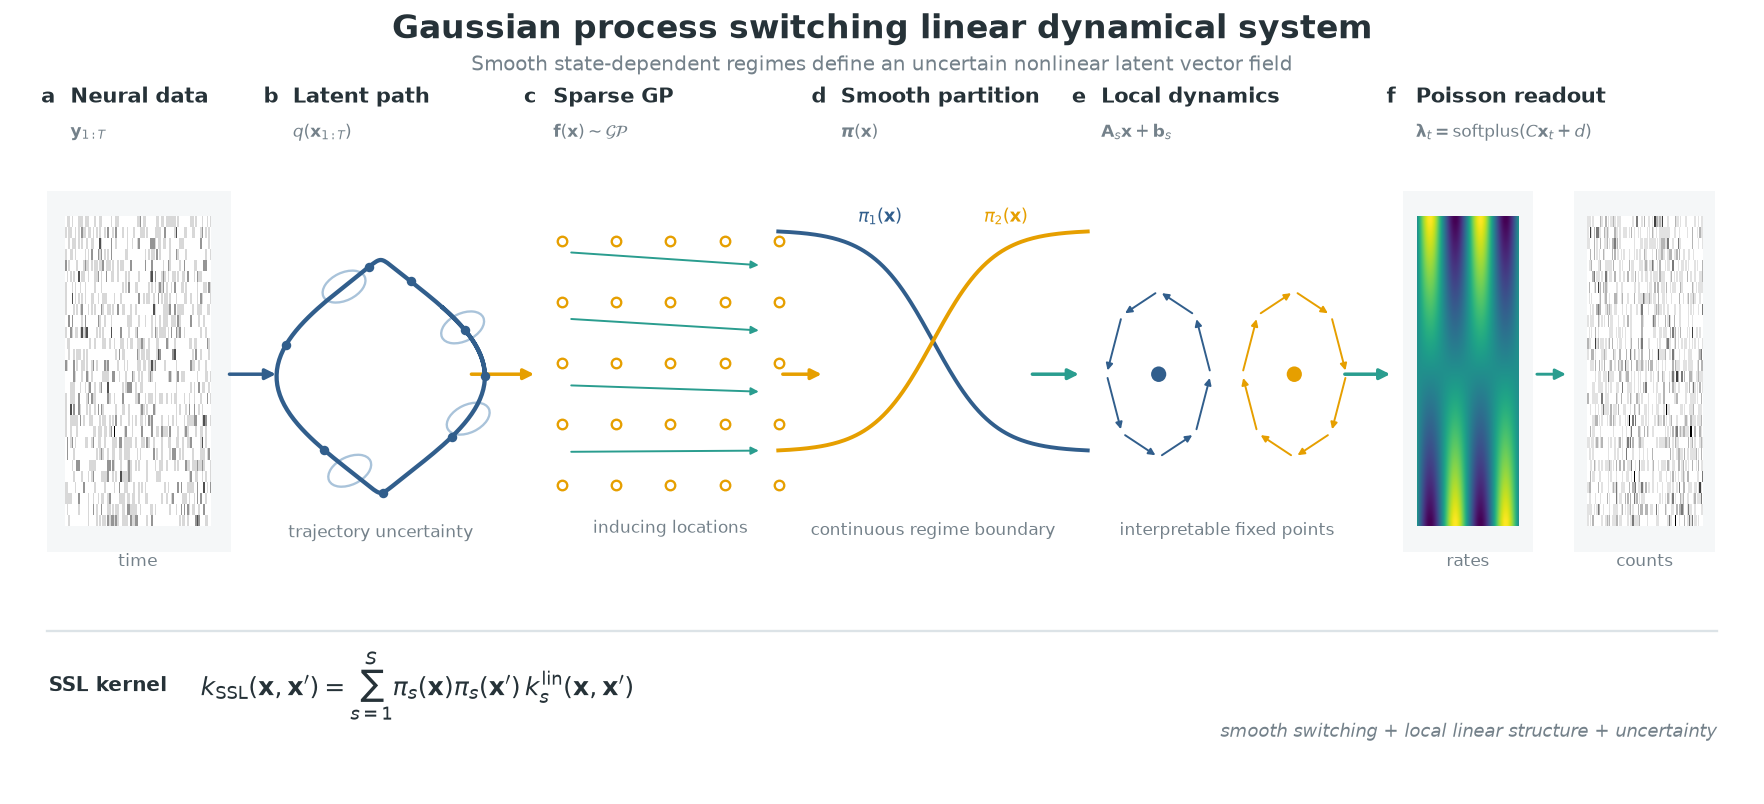

In [2]:
# Draw a publication-style overview of the gpSLDS model.
navy = "#315E8C"
teal = "#2A9D8F"
amber = "#E69F00"
orange = "#D55E00"
ink = "#263238"
muted = "#74818A"
grid_color = "#DCE3E7"
panel_bg = "#F5F7F8"

fig, ax = plt.subplots(figsize=(16, 7.2), dpi=140)
fig.patch.set_facecolor("white")
ax.set_xlim(0, 16)
ax.set_ylim(0, 7)
ax.axis("off")


def arrow(start, end, color=ink, width=1.5, style="-", mutation=11, rad=0.0):
    patch = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=mutation,
        linewidth=width,
        linestyle=style,
        color=color,
        connectionstyle=f"arc3,rad={rad}",
        shrinkA=2,
        shrinkB=2,
    )
    ax.add_patch(patch)


def panel_label(x, letter, title, subtitle):
    ax.text(x, 6.20, letter, fontsize=11, fontweight="bold", color=ink)
    ax.text(x + 0.27, 6.20, title, fontsize=10.8, fontweight="bold", color=ink)
    ax.text(x + 0.27, 5.89, subtitle, fontsize=8.7, color=muted)


ax.text(
    8,
    6.78,
    "Gaussian process switching linear dynamical system",
    ha="center",
    fontsize=17,
    fontweight="bold",
    color=ink,
)
ax.text(
    8,
    6.49,
    "Smooth state-dependent regimes define an uncertain nonlinear latent vector field",
    ha="center",
    fontsize=10.5,
    color=muted,
)

# Observation raster
panel_label(0.25, "a", "Neural data", r"$\mathbf{y}_{1:T}$")
rng = np.random.default_rng(3)
rate_pattern = 0.18 + 0.55 * (
    np.sin(np.linspace(0, 4 * np.pi, 90))[None, :]
    * np.linspace(-1, 1, 28)[:, None]
    + 1
) / 2
spike_pattern = rng.poisson(rate_pattern)
ax.add_patch(Rectangle((0.30, 2.15), 1.70, 3.25, facecolor=panel_bg, edgecolor="none", zorder=0))
ax.imshow(
    spike_pattern,
    extent=(0.47, 1.82, 2.38, 5.18),
    origin="lower",
    aspect="auto",
    cmap="Greys",
    interpolation="nearest",
    zorder=2,
    vmin=0,
    vmax=max(1, spike_pattern.max()),
)
ax.text(1.14, 2.02, "time", ha="center", fontsize=8.5, color=muted)

# Latent trajectory
panel_label(2.30, "b", "Latent path", r"$q(\mathbf{x}_{1:T})$")
t = np.linspace(0, 2.2 * np.pi, 160)
latent_x = 3.38 + 0.78 * np.cos(t) + 0.18 * np.cos(3 * t)
latent_y = 3.73 + 1.05 * np.sin(t)
ax.plot(latent_x, latent_y, color=navy, linewidth=2.2)
for idx in (10, 52, 94, 136):
    ax.add_patch(Ellipse((latent_x[idx], latent_y[idx]), 0.42, 0.25,
                         angle=25, facecolor="none", edgecolor="#A9C3DA", linewidth=1.2))
ax.scatter(latent_x[::22], latent_y[::22], s=15, color=navy, zorder=4)
ax.text(3.38, 2.28, "trajectory uncertainty", ha="center", fontsize=8.5, color=muted)
arrow((1.95, 3.75), (2.45, 3.75), navy, 1.8)

# GP and inducing points
panel_label(4.70, "c", "Sparse GP", r"$\mathbf{f}(\mathbf{x})\sim\mathcal{GP}$")
gx, gy = np.meshgrid(np.linspace(5.05, 7.05, 5), np.linspace(2.75, 4.95, 5))
ax.scatter(gx, gy, s=24, facecolor="white", edgecolor=amber, linewidth=1.2, zorder=4)
ax.text(6.05, 2.32, "inducing locations", ha="center", fontsize=8.5, color=muted)
for y in (3.05, 3.65, 4.25, 4.85):
    arrow((5.10, y), (6.90, y + 0.12 * np.sin(y)), teal, 1.0, mutation=8)
arrow((4.18, 3.75), (4.83, 3.75), amber, 1.8)

# Partition function
panel_label(7.35, "d", "Smooth partition", r"$\boldsymbol{\pi}(\mathbf{x})$")
xx = np.linspace(-2.3, 2.3, 160)
pi_left = 1 / (1 + np.exp(2.2 * xx))
ax.plot(8.47 + 0.62 * xx, 3.05 + 2.0 * pi_left, color=navy, linewidth=2)
ax.plot(8.47 + 0.62 * xx, 3.05 + 2.0 * (1 - pi_left), color=amber, linewidth=2)
ax.text(7.78, 5.12, r"$\pi_1(\mathbf{x})$", color=navy, fontsize=9)
ax.text(8.94, 5.12, r"$\pi_2(\mathbf{x})$", color=amber, fontsize=9)
ax.text(8.47, 2.30, "continuous regime boundary", ha="center", fontsize=8.5, color=muted)
arrow((7.05, 3.75), (7.48, 3.75), amber, 1.8)

# Local linear dynamics
panel_label(9.75, "e", "Local dynamics", r"$\mathbf{A}_s\mathbf{x}+\mathbf{b}_s$")
for center, color, direction in (((10.55, 3.75), navy, 1), ((11.80, 3.75), amber, -1)):
    cx, cy = center
    theta = np.linspace(0, 2 * np.pi, 9)[:-1]
    px = cx + 0.48 * np.cos(theta)
    py = cy + 0.75 * np.sin(theta)
    for j in range(len(theta)):
        k = (j + direction) % len(theta)
        arrow((px[j], py[j]), (px[k], py[k]), color, 1.0, mutation=7)
    ax.add_patch(Circle(center, 0.07, facecolor=color, edgecolor="none"))
ax.text(11.18, 2.30, "interpretable fixed points", ha="center", fontsize=8.5, color=muted)
arrow((9.35, 3.75), (9.85, 3.75), teal, 1.8)

# Poisson emission
panel_label(12.65, "f", "Poisson readout", r"$\boldsymbol{\lambda}_t=\operatorname{softplus}(C\mathbf{x}_t+d)$")
rate_map = np.clip(rate_pattern * 2.5, 0, None)
ax.add_patch(Rectangle((12.80, 2.15), 1.20, 3.25, facecolor=panel_bg, edgecolor="none", zorder=0))
ax.imshow(rate_map, extent=(12.93, 13.87, 2.38, 5.18), origin="lower",
          aspect="auto", cmap="viridis", interpolation="bilinear", zorder=2)
ax.add_patch(Rectangle((14.38, 2.15), 1.30, 3.25, facecolor=panel_bg, edgecolor="none", zorder=0))
generated = rng.poisson(rate_map * 0.55)
ax.imshow(generated, extent=(14.50, 15.57, 2.38, 5.18), origin="lower",
          aspect="auto", cmap="Greys", interpolation="nearest",
          vmin=0, vmax=max(1, generated.max()), zorder=2)
arrow((12.23, 3.75), (12.72, 3.75), teal, 1.8)
arrow((14.00, 3.75), (14.34, 3.75), teal, 1.5)
ax.text(13.40, 2.02, "rates", ha="center", fontsize=8.5, color=muted)
ax.text(15.03, 2.02, "counts", ha="center", fontsize=8.5, color=muted)

# Kernel equation
ax.plot([0.30, 15.70], [1.43, 1.43], color=grid_color, linewidth=1.2)
ax.text(0.32, 0.94, "SSL kernel", fontsize=10.5, fontweight="bold", color=ink, va="center")
ax.text(
    1.72,
    0.94,
    r"$k_{\mathrm{SSL}}(\mathbf{x},\mathbf{x}')"
    r"=\sum_{s=1}^{S}\pi_s(\mathbf{x})\pi_s(\mathbf{x}')"
    r"\,k_s^{\mathrm{lin}}(\mathbf{x},\mathbf{x}')$",
    fontsize=13,
    color=ink,
    va="center",
)
ax.text(15.70, 0.48, "smooth switching + local linear structure + uncertainty",
        ha="right", fontsize=9, color=muted, style="italic")

plt.show()

## 4. Smoothly switching linear kernel

The released implementation defines one linear kernel per regime and combines them using the partition probabilities:

$$
k_{\mathrm{SSL}}(\mathbf{x},\mathbf{x}')
=
\sum_{s=1}^{S}
\pi_s(\mathbf{x})
\pi_s(\mathbf{x}')
k_s^{\mathrm{lin}}(\mathbf{x},\mathbf{x}').
$$

For the local kernel used here,

$$
k_s^{\mathrm{lin}}(\mathbf{x},\mathbf{x}')
=
(\mathbf{x}-\mathbf{c}_s)^\top
\mathbf{M}_s
(\mathbf{x}'-\mathbf{c}_s)
+\sigma_s^2,
$$

where $\mathbf{c}_s$ is an interpretable fixed-point location. Multiplication by $\pi_s(\mathbf{x})\pi_s(\mathbf{x}')$ suppresses a regime's covariance away from its preferred region.

In [3]:
latent_dim = 2
quadrature = GaussHermiteQuadrature(latent_dim, n_quad=6)
linear_kernel = Linear(quadrature, noise_var=0.15)
basis_set = lambda x: jnp.array([1.0, x[0], x[1]])
kernel = SSL(quadrature, linear_kernel, basis_set=basis_set)

# State 0 dominates for positive x1; state 1 dominates for negative x1.
fixed_points = jnp.array([[3.0, 0.0], [-3.0, 0.0]])
kernel_params = {
    "linear_params": [
        {"fixed_point": fixed_points[0]},
        {"fixed_point": fixed_points[1]},
    ],
    "W": jnp.array([[0.0], [1.0], [0.0]]),
    "log_tau": jnp.log(0.55),
}

partition_fn = lambda x: kernel.construct_partition(
    x, kernel_params["W"], kernel_params["log_tau"]
)
print("partition at x1=-3:", partition_fn(jnp.array([-3.0, 0.0])))
print("partition at x1=+3:", partition_fn(jnp.array([+3.0, 0.0])))

partition at x1=-3: [0.00425861 0.99574139]
partition at x1=+3: [0.99574139 0.00425861]


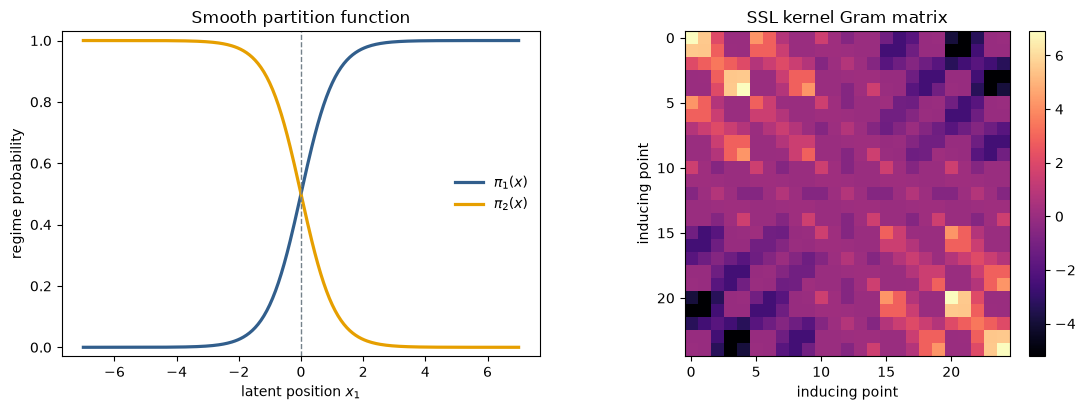

minimum Gram eigenvalue: 9.99999665308305e-09


In [4]:
x_axis = jnp.linspace(-7.0, 7.0, 300)
partition_line = vmap(lambda x1: partition_fn(jnp.array([x1, 0.0])))(x_axis)

inducing_points = initialize_zs(latent_dim, zs_lim=6.0, num_per_dim=5)
gram = make_gram(kernel.K, kernel_params, inducing_points, inducing_points)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(x_axis, partition_line[:, 0], color="#315E8C", linewidth=2.3, label=r"$\pi_1(x)$")
axes[0].plot(x_axis, partition_line[:, 1], color="#E69F00", linewidth=2.3, label=r"$\pi_2(x)$")
axes[0].axvline(0, color="#74818A", linewidth=1, linestyle="--")
axes[0].set(xlabel=r"latent position $x_1$", ylabel="regime probability", ylim=(-0.03, 1.03), title="Smooth partition function")
axes[0].legend(frameon=False)

image = axes[1].imshow(np.asarray(gram), cmap="magma")
axes[1].set(title="SSL kernel Gram matrix", xlabel="inducing point", ylabel="inducing point")
fig.colorbar(image, ax=axes[1], fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

print("minimum Gram eigenvalue:", float(jnp.linalg.eigvalsh(gram).min()))

## 5. Synthetic switching dynamics

We construct two rotational linear systems with fixed points on opposite sides of the latent space. The same partition function used by the SSL kernel blends their drift fields. Euler-Maruyama integration produces stochastic latent trajectories:

$$
\mathbf{x}_{t+1}
=
\mathbf{x}_t
+
\Delta t\,\mathbf{f}(\mathbf{x}_t)
+
\sqrt{\Delta t}\,\sigma\boldsymbol{\epsilon}_t,
\qquad
\boldsymbol{\epsilon}_t\sim\mathcal{N}(\mathbf{0},\mathbf{I}).
$$

In [5]:
A_right = jnp.array([[0.04, -1.10], [1.10, 0.04]])
A_left = jnp.array([[0.04, 1.10], [-1.10, 0.04]])


def true_drift(x):
    probabilities = partition_fn(x)
    right_drift = A_right @ (x - fixed_points[0])
    left_drift = A_left @ (x - fixed_points[1])
    return probabilities[0] * right_drift + probabilities[1] * left_drift


def simulate_trial(key, initial_state, n_steps=220, dt=0.02, noise_scale=0.18):
    keys = jr.split(key, n_steps)

    def step(state, step_key):
        noise = noise_scale * jnp.sqrt(dt) * jr.normal(step_key, state.shape)
        next_state = state + dt * true_drift(state) + noise
        return next_state, state

    _, states = lax.scan(step, initial_state, keys)
    return states


dt = 0.02
n_steps = 220
n_trials = 12
key = jr.PRNGKey(23)
trial_keys = jr.split(key, n_trials)
initial_states = jnp.vstack([
    jnp.tile(jnp.array([-5.5, 0.0]), (n_trials // 2, 1)),
    jnp.tile(jnp.array([+5.5, 0.0]), (n_trials - n_trials // 2, 1)),
])
latent_states = vmap(lambda k, x0: simulate_trial(k, x0, n_steps, dt))(trial_keys, initial_states)
latent_states.shape

(12, 220, 2)

In [6]:
# Generate Poisson neural observations from the latent trajectories.
key, key_C, key_d, key_spikes = jr.split(key, 4)
n_neurons = 28
C = 0.32 * jr.normal(key_C, (n_neurons, latent_dim))
d = 2.1 + 0.25 * jr.normal(key_d, (n_neurons,))
rates = 12.0 * softplus(jnp.einsum("ntk,dk->ntd", latent_states, C) + d)
spike_counts = jr.poisson(key_spikes, rates * dt)

t_mask = jnp.ones((n_trials, n_steps), dtype=bool)
trial_mask = jnp.ones((n_trials, n_steps), dtype=bool)

print("ys_binned:", spike_counts.shape)
print("t_mask:", t_mask.shape)
print("trial_mask:", trial_mask.shape)

ys_binned: (12, 220, 28)
t_mask: (12, 220)
trial_mask: (12, 220)


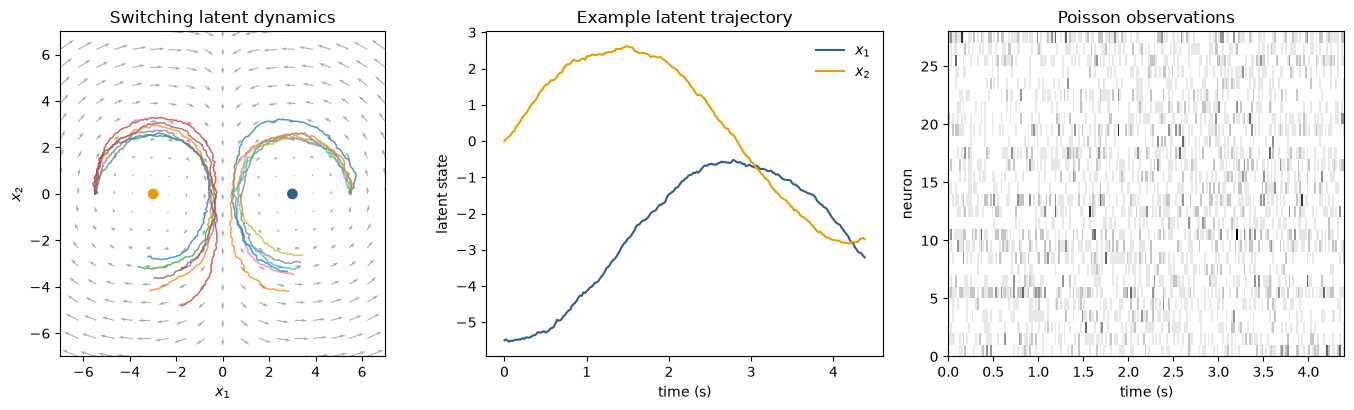

In [7]:
grid_axis = jnp.linspace(-7.0, 7.0, 19)
grid_x1, grid_x2 = jnp.meshgrid(grid_axis, grid_axis)
grid_points = jnp.column_stack([grid_x1.ravel(), grid_x2.ravel()])
true_vectors = vmap(true_drift)(grid_points)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
axes[0].quiver(grid_points[:, 0], grid_points[:, 1], true_vectors[:, 0], true_vectors[:, 1], color="#74818A", alpha=0.65)
for trial in np.asarray(latent_states):
    axes[0].plot(trial[:, 0], trial[:, 1], linewidth=1.1, alpha=0.75)
axes[0].scatter(np.asarray(fixed_points)[:, 0], np.asarray(fixed_points)[:, 1], s=45, color=["#315E8C", "#E69F00"], zorder=5)
axes[0].set(xlim=(-7, 7), ylim=(-7, 7), xlabel=r"$x_1$", ylabel=r"$x_2$", title="Switching latent dynamics")
axes[0].set_aspect("equal")

time = np.arange(n_steps) * dt
axes[1].plot(time, np.asarray(latent_states[0, :, 0]), color="#315E8C", label=r"$x_1$")
axes[1].plot(time, np.asarray(latent_states[0, :, 1]), color="#E69F00", label=r"$x_2$")
axes[1].set(xlabel="time (s)", ylabel="latent state", title="Example latent trajectory")
axes[1].legend(frameon=False)

axes[2].imshow(np.asarray(spike_counts[0]).T, aspect="auto", interpolation="nearest", cmap="Greys", origin="lower", extent=(0, n_steps * dt, 0, n_neurons))
axes[2].set(xlabel="time (s)", ylabel="neuron", title="Poisson observations")

fig.tight_layout()
plt.show()

## 6. Inducing-point GP conditioning

Sparse GP inference summarizes the drift field at inducing locations $\mathbf{Z}=\{\mathbf{z}_m\}_{m=1}^{M}$. For this controlled demonstration, the drift values at those locations are treated as observed. The GP conditional mean at query points $\mathbf{X}$ is

$$
\mathbb{E}[\mathbf{f}(\mathbf{X})\mid\mathbf{f}(\mathbf{Z})]
=
\mathbf{K}_{XZ}
\mathbf{K}_{ZZ}^{-1}
\mathbf{f}(\mathbf{Z}),
$$

and the marginal posterior variance is obtained from

$$
\operatorname{diag}\!\left(
\mathbf{K}_{XX}
-
\mathbf{K}_{XZ}\mathbf{K}_{ZZ}^{-1}\mathbf{K}_{ZX}
\right).
$$

In the complete gpSLDS variational EM algorithm, the inducing values and latent trajectories are uncertain and learned jointly from observations.

In [8]:
inducing_values = vmap(true_drift)(inducing_points)
Kzz = make_gram(kernel.K, kernel_params, inducing_points, inducing_points, jitter=1e-6)
Kxz = make_gram(kernel.K, kernel_params, grid_points, inducing_points, jitter=None)

alpha = jnp.linalg.solve(Kzz, inducing_values)
gp_mean = Kxz @ alpha

prior_diagonal = vmap(lambda x: kernel.K(x, x, kernel_params))(grid_points)
solved_cross_covariance = jnp.linalg.solve(Kzz, Kxz.T).T
gp_variance = jnp.clip(
    prior_diagonal - jnp.sum(Kxz * solved_cross_covariance, axis=1),
    min=0.0,
)

vector_rmse = jnp.sqrt(jnp.mean((gp_mean - true_vectors) ** 2))
print(f"vector-field RMSE: {float(vector_rmse):.4f}")
print(f"posterior variance range: {float(gp_variance.min()):.6f} to {float(gp_variance.max()):.6f}")

vector-field RMSE: 0.0000
posterior variance range: 0.000000 to 0.000001


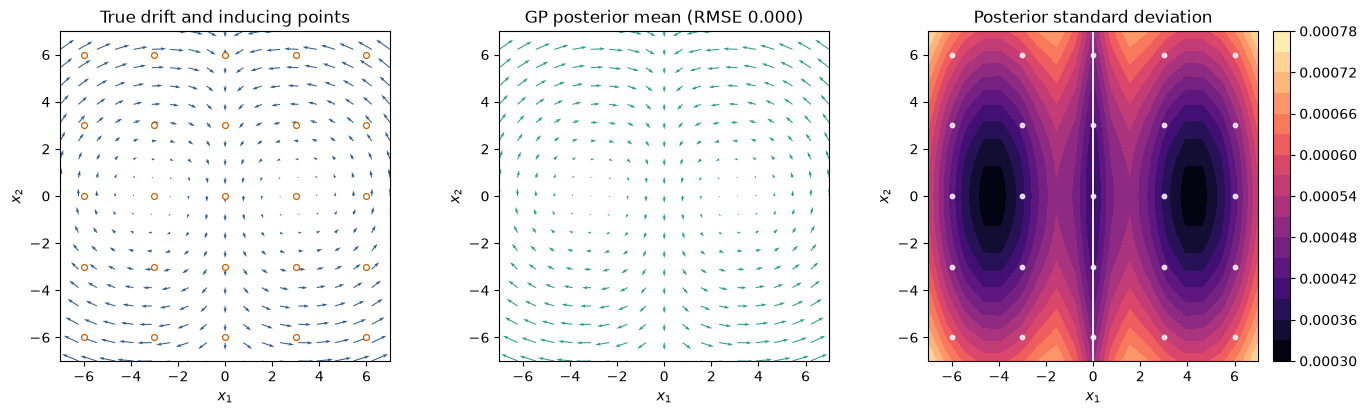

In [9]:
partition_grid = vmap(partition_fn)(grid_points)[:, 0].reshape(grid_x1.shape)
uncertainty_grid = jnp.sqrt(gp_variance).reshape(grid_x1.shape)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

axes[0].quiver(grid_points[:, 0], grid_points[:, 1], true_vectors[:, 0], true_vectors[:, 1], color="#315E8C")
axes[0].scatter(np.asarray(inducing_points)[:, 0], np.asarray(inducing_points)[:, 1], s=18, facecolor="white", edgecolor="#D55E00", linewidth=0.9)
axes[0].set(title="True drift and inducing points", xlabel=r"$x_1$", ylabel=r"$x_2$")

axes[1].quiver(grid_points[:, 0], grid_points[:, 1], gp_mean[:, 0], gp_mean[:, 1], color="#2A9D8F")
axes[1].set(title=f"GP posterior mean (RMSE {float(vector_rmse):.3f})", xlabel=r"$x_1$", ylabel=r"$x_2$")

image = axes[2].contourf(grid_x1, grid_x2, uncertainty_grid, levels=16, cmap="magma")
axes[2].contour(grid_x1, grid_x2, partition_grid, levels=[0.5], colors="white", linewidths=1.3)
axes[2].scatter(np.asarray(inducing_points)[:, 0], np.asarray(inducing_points)[:, 1], s=10, color="white", alpha=0.8)
axes[2].set(title="Posterior standard deviation", xlabel=r"$x_1$", ylabel=r"$x_2$")
fig.colorbar(image, ax=axes[2], fraction=0.046, pad=0.04)

for axis in axes:
    axis.set_xlim(-7, 7)
    axis.set_ylim(-7, 7)
    axis.set_aspect("equal")

fig.tight_layout()
plt.show()

## 7. Quadrature under uncertain latent states

Variational inference represents each latent state with a Gaussian approximation. Kernel expectations such as

$$
\mathbb{E}_{q(\mathbf{x})}
\left[k(\mathbf{x},\mathbf{z})\right],
\qquad
q(\mathbf{x})=\mathcal{N}(\mathbf{m},\mathbf{S}),
$$

are generally unavailable in closed form for the SSL kernel. The repository's `GaussHermiteQuadrature` object evaluates these expectations using deterministic sigma points.

In [10]:
q_mean = jnp.array([0.25, -0.30])
q_covariance = jnp.array([[0.45, 0.12], [0.12, 0.30]])
reference_inducing_point = inducing_points[len(inducing_points) // 2]

expected_self_kernel = kernel.E_Kxx(q_mean, q_covariance, kernel_params)
expected_cross_kernel = kernel.E_Kxz(
    reference_inducing_point, q_mean, q_covariance, kernel_params
)
expected_kernel_outer = kernel.E_KzxKxz(
    reference_inducing_point,
    reference_inducing_point,
    q_mean,
    q_covariance,
    kernel_params,
)

print(f"E[k(x, x)]       = {float(expected_self_kernel):.6f}")
print(f"E[k(x, z)]       = {float(expected_cross_kernel):.6f}")
print(f"E[k(z, x)k(x,z)] = {float(expected_kernel_outer):.6f}")

E[k(x, x)]       = 0.716057
E[k(x, z)]       = 0.670952
E[k(z, x)k(x,z)] = 0.458284


## 8. Local linear interpretation

The posterior mean drift remains nonlinear globally, but its Jacobian at any latent location gives a local linear approximation:

$$
\mathbf{f}(\mathbf{x})
\approx
\mathbf{f}(\mathbf{x}^{\star})
+
\mathbf{J}_{\mathbf{f}}(\mathbf{x}^{\star})
(\mathbf{x}-\mathbf{x}^{\star}).
$$

Eigenvalues of $\mathbf{J}_{\mathbf{f}}$ characterize local contraction, expansion, and rotation. This connects the flexible GP representation back to familiar dynamical-systems analysis.

In [11]:
def gp_posterior_mean_at(x):
    cross_covariance = vmap(
        lambda z: kernel.K(x, z, kernel_params)
    )(inducing_points)
    return cross_covariance @ alpha


diagnostic_points = jnp.array([[-3.0, 0.0], [0.0, 0.0], [3.0, 0.0]])
jacobians = vmap(jacfwd(gp_posterior_mean_at))(diagnostic_points)
eigenvalues = vmap(jnp.linalg.eigvals)(jacobians)

for point, jacobian, values in zip(
    np.asarray(diagnostic_points),
    np.asarray(jacobians),
    np.asarray(eigenvalues),
):
    print(f"point {point}")
    print(np.array2string(jacobian, precision=3, suppress_small=True))
    print("eigenvalues:", np.array2string(values, precision=3))
    print()

point [-3.  0.]
[[ 0.038  1.091]
 [-1.142  0.04 ]]
eigenvalues: [0.039+1.116j 0.039-1.116j]

point [0. 0.]
[[-0.069  0.   ]
 [-0.     0.04 ]]
eigenvalues: [-0.069+0.j  0.04 +0.j]

point [3. 0.]
[[ 0.038 -1.091]
 [ 1.142  0.04 ]]
eigenvalues: [0.039+1.116j 0.039-1.116j]



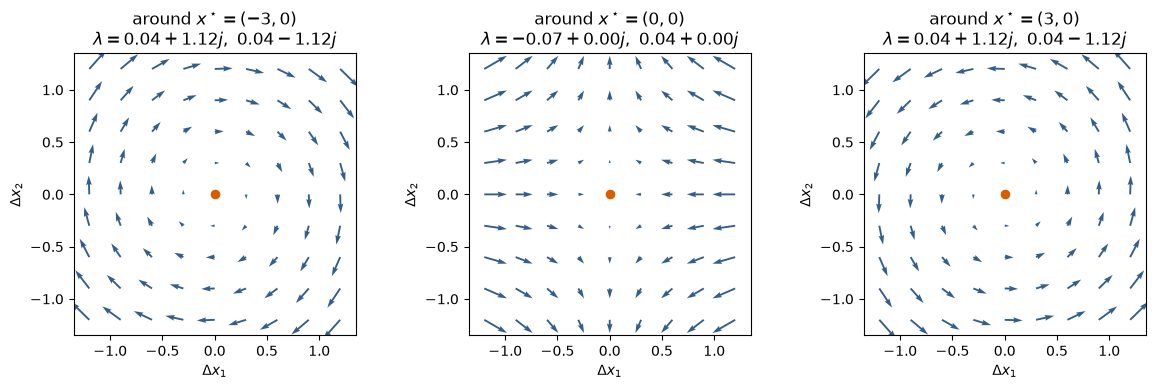

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
for axis, point, jacobian, values in zip(
    axes,
    np.asarray(diagnostic_points),
    np.asarray(jacobians),
    np.asarray(eigenvalues),
):
    local_axis = np.linspace(-1.2, 1.2, 9)
    local_x1, local_x2 = np.meshgrid(local_axis, local_axis)
    displacements = np.column_stack([local_x1.ravel(), local_x2.ravel()])
    local_vectors = displacements @ jacobian.T
    axis.quiver(displacements[:, 0], displacements[:, 1], local_vectors[:, 0], local_vectors[:, 1], color="#315E8C")
    axis.scatter([0], [0], s=35, color="#D55E00", zorder=4)
    axis.set_title(
        rf"around $x^\star=({point[0]:.0f},{point[1]:.0f})$"
        + "\n"
        + rf"$\lambda={values[0]:.2f},\ {values[1]:.2f}$"
    )
    axis.set(xlabel=r"$\Delta x_1$", ylabel=r"$\Delta x_2$", xlim=(-1.35, 1.35), ylim=(-1.35, 1.35))
    axis.set_aspect("equal")
fig.tight_layout()
plt.show()

## 9. Data contract for full variational EM

The upstream `fit_variational_em` function expects:

- `ys_binned`: shape `(n_trials, n_timesteps, n_output_dims)`;
- `t_mask`: shape `(n_trials, n_timesteps)`, marking observed bins;
- `trial_mask`: shape `(n_trials, n_timesteps)`, marking valid non-padded bins;
- optional known inputs with shape `(n_trials, n_timesteps, n_input_dims)`.

The arrays created in this notebook already follow that contract. The original fitting pipeline alternates between approximate latent-state inference and optimization of likelihood, inducing-point, and SSL-kernel parameters. It was designed for a GPU backend and used an NVIDIA A100 for the paper experiments. Running that exact pipeline requires a separate environment compatible with the repository's TensorFlow Probability and `ssm` dependencies.

In [13]:
data_contract = {
    "ys_binned": spike_counts,
    "t_mask": t_mask,
    "trial_mask": trial_mask,
    "inputs": None,
}

for name, value in data_contract.items():
    print(f"{name:12s}: {None if value is None else value.shape}")

ys_binned   : (12, 220, 28)
t_mask      : (12, 220)
trial_mask  : (12, 220)
inputs      : None


## 10. Summary

gpSLDS combines three useful properties:

1. **Interpretability:** each regime is anchored by a local linear dynamical component.
2. **Smoothness:** state-dependent partition functions remove discontinuous switching boundaries.
3. **Uncertainty:** the Gaussian process quantifies uncertainty in the inferred vector field, especially away from inducing points and observed trajectories.

The core distinction from LFADS is that gpSLDS places an explicit probabilistic prior directly on the latent drift field. LFADS learns dynamics through a recurrent neural network, whereas gpSLDS exposes local linear structure, regime probabilities, and function-space posterior uncertainty.